In this notebook, a recommendation system is built to:

- Return the top *k* dishes based on a user query.
- Display recommended dishes when the user enters the site, based on their previous orders.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
import pandas as pd
import numpy as np
import os

In [8]:
working_directory = "/content/drive/MyDrive/transformers/Restaurant/Find_Meals"

In [10]:
os.chdir(working_directory)

In [11]:
os.getcwd()

'/content/drive/MyDrive/transformers/Restaurant/Find_Meals'

In [12]:
!ls

cosine_similarity_matrix.ipynb	indian_food.zip
cosine_similarity_matrix.npy	meal_recommendation_system.ipynb
indian_food.csv			product_embeddings.npy


In [16]:
df = pd.read_csv("./indian_food.csv")

In [17]:
df.head()

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45,25,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            255 non-null    object
 1   ingredients     255 non-null    object
 2   diet            255 non-null    object
 3   prep_time       255 non-null    int64 
 4   cook_time       255 non-null    int64 
 5   flavor_profile  255 non-null    object
 6   course          255 non-null    object
 7   state           255 non-null    object
 8   region          254 non-null    object
dtypes: int64(2), object(7)
memory usage: 18.1+ KB


In [93]:
embeddings = np.load("./product_embeddings.npy")

In [94]:
embeddings

array([[ 0.0163672 ,  0.05465626,  0.03164252, ...,  0.02864694,
         0.00851698, -0.02645836],
       [-0.00554581,  0.01783556,  0.06132139, ...,  0.02343436,
         0.02231711, -0.01004459],
       [ 0.01632514,  0.08825903,  0.00926736, ...,  0.02608406,
        -0.03759384, -0.02179034],
       ...,
       [ 0.0074555 ,  0.07032397,  0.03712026, ...,  0.03917303,
        -0.00517352,  0.02663715],
       [ 0.03465152, -0.00861237,  0.03045205, ..., -0.00079639,
         0.02357826, -0.00452019],
       [ 0.03357434,  0.0305451 ,  0.05412727, ..., -0.0217205 ,
         0.02458404,  0.00946234]], dtype=float32)

In [13]:
similarity_matrix = np.load("./cosine_similarity_matrix.npy")

In [14]:
similarity_matrix

array([[1.        , 0.8312722 , 0.7901525 , ..., 0.8049377 , 0.84266615,
        0.67274094],
       [0.8312722 , 1.        , 0.7843121 , ..., 0.7976359 , 0.8211512 ,
        0.7258732 ],
       [0.7901525 , 0.7843121 , 0.99999994, ..., 0.7554959 , 0.71699333,
        0.6528256 ],
       ...,
       [0.8049377 , 0.7976359 , 0.7554959 , ..., 0.9999999 , 0.77195626,
        0.69954675],
       [0.84266615, 0.8211512 , 0.71699333, ..., 0.77195626, 1.0000002 ,
        0.7095849 ],
       [0.67274094, 0.7258732 , 0.6528256 , ..., 0.69954675, 0.7095849 ,
        1.        ]], dtype=float32)

# 1. Display top dishes based on semantic meaning

In [96]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

In [100]:
model_name= "distiluse-base-multilingual-cased-v1"

In [ ]:
embedding_model = SentenceTransformer(model_name)

In [102]:
def get_top_dishes_indices_by_similarity(user_search, model = embedding_model, embeddings = embeddings,top_k = 10):
  user_embedding = model.encode([user_search])
  similarities = cosine_similarity(user_embedding, embeddings)
  similarities = similarities[0]
  top_indices = np.argsort(similarities)[-top_k:][::-1]
  return top_indices



###  Now it’s time to test

In [109]:
user_search = "vegetarian dish, spicy flavor, main course"
indices= get_top_dishes_indices_by_similarity(user_search)
df.iloc[indices, [0, 1, 5, 6]]

,name,ingredients,flavor_profile,course
152,Poriyal,"Chana dal, urad dal, beans, coconut, mustard",spicy,main course
223,Kumol Sawul,"Rice, eggs, carrot, beetroot",spicy,main course
137,Beef Fry,"Beef, coconut, garam masala, curry leaves, gre...",spicy,main course
194,Laapsi,"Cinnamon, jaggery, clarified butter, dry roasted",spicy,main course
138,Kootu,"Chana dal, urad dal, potato, beans, peas",spicy,main course
70,Aloo matar,"Potato, peas, chillies, ginger, garam masala, ...",spicy,main course
210,Veg Kolhapuri,"Gobi, potato, beans, khus khus, coconut",spicy,main course
166,Zunka,"Gram flour, mustard, garlic, turmeric, red chilli",spicy,main course
195,Koshimbir,"Cucumber, carrot, tomatoes, cilantro",spicy,main course
225,Alu Pitika,"Potatoes, mustard oil, fish, green chillies",spicy,main course


In [110]:
user_search = "sweet indian dessert with milk"
indices= get_top_dishes_indices_by_similarity(user_search)
df.iloc[indices, [0, 1, 5, 6]]

,name,ingredients,flavor_profile,course
29,Misti doi,"Milk, jaggery",sweet,dessert
40,Dharwad pedha,"Milk, Sugar, Dharwadi buffalo milk",sweet,dessert
8,Kalakand,"Milk, cottage cheese, sugar",sweet,dessert
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",sweet,dessert
170,Coconut vadi,"Condensed milk, mawa, desiccated coconut, almo...",sweet,dessert
47,Palathalikalu,"Rice flour, milk",sweet,dessert
58,Doodhpak,"Milk, rice, sugar, dry fruits",sweet,dessert
21,Chhena kheeri,"Chhena, sugar, milk",sweet,dessert
45,Mysore pak,"Besan flour, semolina, mung bean, jaggery, coc...",sweet,dessert
11,Lassi,"Yogurt, milk, nuts, sugar",sweet,dessert


In [112]:
user_search = "creamy curry made with paneer, butter, tomato sauce, cream, and mild spices"
indices= get_top_dishes_indices_by_similarity(user_search)
df.iloc[indices, [0, 1, 5, 6]]

,name,ingredients,flavor_profile,course
132,Kaara kozhambu,"Sesame oil, drumstick, tamarind paste, sambar ...",spicy,main course
107,Paneer butter masala,"Paneer, whipping cream, garam masala, cashew n...",spicy,main course
183,Gatta curry,"Yogurt, besan, sauce, garam masala powder, gra...",spicy,main course
74,Bhindi masala,"Ladies finger, garam masala, kasuri methi, tom...",spicy,main course
108,Paneer tikka masala,"Paneer, greek yogurt, tandoori masala, cream, ...",spicy,main course
91,Kadai paneer,"Cottage cheese, bell peppers, gravy, garam mas...",spicy,main course
92,Kadhi pakoda,"Besan, garam masala powder, gram flour, ginger...",spicy,main course
154,Rasam,"Tomato, curry leaves, garlic, mustard seeds, h...",spicy,main course
77,Chana masala,"Chickpeas, tomato paste, garam masala, ginger,...",spicy,main course
93,Karela bharta,"Bitter gourd, fennel, garam masala powder, chi...",bitter,main course


# 2. Show recommendations based on the user's previous orders

In [56]:
def get_dish_index_by_name(dish_name):
  matches = df[df["name"] == dish_name]
  if matches.empty:
    return None
  return matches.index[0]

In [57]:
get_dish_index_by_name("Boondi")

np.int64(1)

In [60]:
def get_dish_name_by_index(index):
  return df.iloc[index, 0]

In [62]:
get_dish_name_by_index(5)

'Imarti'

In [127]:
previous_orders = df.sample(n=5)["name"].tolist()

In [128]:
previous_orders

['Namakpara', 'Aloo gobi', 'Paravannam', 'Dal tadka', 'Doodhpak']

In [92]:
def get_top_recommendations(previous_orders, top_k=10):
  indices= [get_dish_index_by_name(order) for order in previous_orders]
  indices = [i for i in indices if i is not None]
  sims= similarity_matrix[indices]
  avg_vector=  sims.mean(axis= 0)
  scores = list(enumerate(avg_vector))
  scores = sorted(scores , key=lambda x: x[1], reverse= True)
  top_scores = scores[:top_k]
  return top_scores

In [129]:
recommendations = get_top_recommendations(previous_orders)

In [130]:
recommendations

[(148, np.float32(0.82287645)),
 (86, np.float32(0.8189548)),
 (138, np.float32(0.81303626)),
 (164, np.float32(0.81217897)),
 (203, np.float32(0.80646706)),
 (153, np.float32(0.8046468)),
 (152, np.float32(0.80312634)),
 (244, np.float32(0.80190974)),
 (92, np.float32(0.8005144)),
 (205, np.float32(0.7999573))]

In [131]:
def show_top_recommendations(recommendations):
  dishes = [get_dish_name_by_index(element[0]) for element in recommendations]
  print(f"Top {len(dishes)} recommended dishes based on the user's past orders: ")
  print()
  for dish in dishes:
    print(dish)


In [132]:
show_top_recommendations(recommendations)

Top 10 recommended dishes based on the user's past orders: 

Paravannam
Dal tadka
Kootu
Upma
Sev khamani
Puli sadam
Poriyal
Pakhala
Kadhi pakoda
Namakpara


In [133]:
import matplotlib.pyplot as plt

In [134]:
names=[get_dish_name_by_index(element[0]) for element in recommendations]
scores = [element[1] for element in recommendations]

In [135]:
names

['Paravannam',
 'Dal tadka',
 'Kootu',
 'Upma',
 'Sev khamani',
 'Puli sadam',
 'Poriyal',
 'Pakhala',
 'Kadhi pakoda',
 'Namakpara']

In [136]:
scores

[np.float32(0.82287645),
 np.float32(0.8189548),
 np.float32(0.81303626),
 np.float32(0.81217897),
 np.float32(0.80646706),
 np.float32(0.8046468),
 np.float32(0.80312634),
 np.float32(0.80190974),
 np.float32(0.8005144),
 np.float32(0.7999573)]

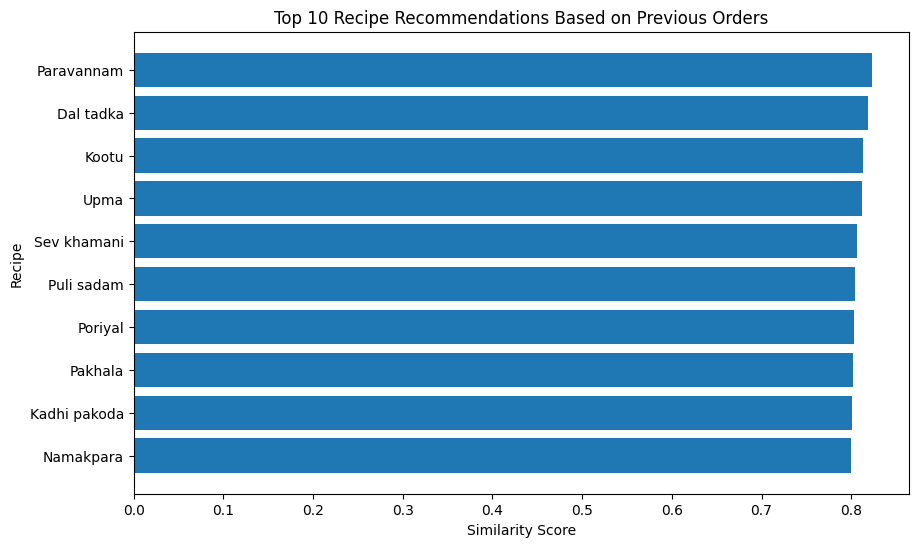

In [142]:
plt.figure(figsize=(10, 6))
plt.barh(names, scores)

plt.xlabel('Similarity Score')
plt.ylabel('Recipe')
plt.title('Top 10 Recipe Recommendations Based on Previous Orders')
plt.gca().invert_yaxis()

plt.show()
